Install / Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from PIL import Image, ImageFilter

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


Load CIFAR-10

In [ ]:
transform_original = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset_original = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_original
)

testset_original = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_original
)

classes = trainset_original.classes
print(classes)
print("Training images:", len(trainset_original))
print("Testing images:", len(testset_original))

100%|██████████| 170M/170M [00:08<00:00, 19.2MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training images: 50000
Testing images: 10000


Create Frequency-Filtered Dataset

In [ ]:
class FrequencyTransform:
    def __init__(self, mode="original", blur_radius=2, noise_std=0.15):
        self.mode = mode
        self.blur_radius = blur_radius
        self.noise_std = noise_std
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(
            (0.5, 0.5, 0.5),
            (0.5, 0.5, 0.5)
        )

    def __call__(self, img):
        # img is a PIL image

        if self.mode == "original":
            out = img

        elif self.mode == "low":
            # Low-frequency image: blurred version
            out = img.filter(ImageFilter.GaussianBlur(radius=self.blur_radius))

        elif self.mode == "high":
            # High-frequency image: original - blurred
            original = np.array(img).astype(np.float32)

            blurred = np.array(
                img.filter(ImageFilter.GaussianBlur(radius=self.blur_radius))
            ).astype(np.float32)

            high = original - blurred

            # Rescale values back into visible image range
            high = high - high.min()
            high = high / (high.max() + 1e-8)
            high = (high * 255).astype(np.uint8)

            out = Image.fromarray(high)

        elif self.mode == "noisy":
            # Add Gaussian noise
            original = np.array(img).astype(np.float32) / 255.0
            noise = np.random.normal(0, self.noise_std, original.shape)
            noisy = original + noise
            noisy = np.clip(noisy, 0, 1)
            noisy = (noisy * 255).astype(np.uint8)

            out = Image.fromarray(noisy)

        else:
            raise ValueError("Mode must be original, low, high, or noisy")

        out = self.to_tensor(out)
        out = self.normalize(out)
        return out

Visualize the Dataset Versions

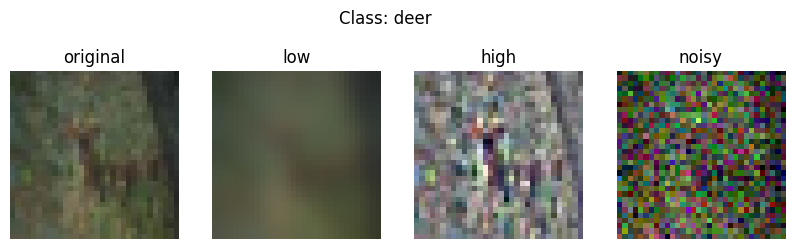

In [ ]:
def show_versions(index=0):
    raw_dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=None
    )

    img, label = raw_dataset[index]

    modes = ["original", "low", "high", "noisy"]

    plt.figure(figsize=(10, 3))

    for i, mode in enumerate(modes):
        transform = FrequencyTransform(mode=mode)
        transformed = transform(img)

        # unnormalize for display
        display_img = transformed * 0.5 + 0.5
        display_img = display_img.permute(1, 2, 0).numpy()
        display_img = np.clip(display_img, 0, 1)

        plt.subplot(1, 4, i + 1)
        plt.imshow(display_img)
        plt.title(mode)
        plt.axis("off")

    plt.suptitle(f"Class: {classes[label]}")
    plt.show()

show_versions(10)

Create DataLoaders

In [ ]:
from torch.utils.data import DataLoader

def get_dataloaders(mode="original", batch_size=64):
    train_transform = FrequencyTransform(mode=mode)
    test_transform = FrequencyTransform(mode=mode)

    trainset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=train_transform
    )

    testset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=test_transform
    )

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    testloader = DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return trainloader, testloader

In [ ]:
trainloader, testloader = get_dataloaders(mode="original", batch_size=64)

images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])


Define Vanilla CNN Model (Baseline)

In [ ]:
class VanillaCNN(nn.Module):
    def __init__(self):
        super(VanillaCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Training and Evaluation Functions

In [ ]:
def train_one_epoch(model, trainloader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, testloader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

Define Baseline Experiment Function

In [ ]:
def run_experiment(mode="original", epochs=10, batch_size=64, lr=0.001):
    print(f"\nRunning experiment: {mode}")

    trainloader, testloader = get_dataloaders(mode=mode, batch_size=batch_size)

    model = VanillaCNN().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, trainloader, criterion, optimizer
        )

        test_loss, test_acc, _, _ = evaluate(
            model, testloader, criterion
        )

        history.append({
            "mode": mode,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc
        })

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
        )

    total_time = time.time() - start_time

    test_loss, test_acc, preds, labels = evaluate(model, testloader, criterion)

    print(f"\nFinished {mode}")
    print(f"Final Test Accuracy: {test_acc:.4f}")
    print(f"Training time: {total_time:.2f} seconds")

    return model, pd.DataFrame(history), preds, labels, total_time

In [ ]:
baseline_model_test, baseline_history_test, baseline_preds_test, baseline_labels_test, baseline_time_test = run_experiment(
    mode="original",
    epochs=10,
    batch_size=64,
    lr=0.001
)


Running experiment: original
Epoch [1/10] Train Loss: 1.3459, Train Acc: 0.5211, Test Loss: 1.1000, Test Acc: 0.6078
Epoch [2/10] Train Loss: 0.9589, Train Acc: 0.6615, Test Loss: 0.9374, Test Acc: 0.6677
Epoch [3/10] Train Loss: 0.8039, Train Acc: 0.7194, Test Loss: 0.8644, Test Acc: 0.6982
Epoch [4/10] Train Loss: 0.6903, Train Acc: 0.7588, Test Loss: 0.8422, Test Acc: 0.7145
Epoch [5/10] Train Loss: 0.5894, Train Acc: 0.7942, Test Loss: 0.8661, Test Acc: 0.7098
Epoch [6/10] Train Loss: 0.4968, Train Acc: 0.8264, Test Loss: 0.8534, Test Acc: 0.7201
Epoch [7/10] Train Loss: 0.4096, Train Acc: 0.8578, Test Loss: 0.8979, Test Acc: 0.7169
Epoch [8/10] Train Loss: 0.3325, Train Acc: 0.8834, Test Loss: 0.9680, Test Acc: 0.7181
Epoch [9/10] Train Loss: 0.2624, Train Acc: 0.9097, Test Loss: 1.0248, Test Acc: 0.7223
Epoch [10/10] Train Loss: 0.2041, Train Acc: 0.9293, Test Loss: 1.1700, Test Acc: 0.7206

Finished original
Final Test Accuracy: 0.7206
Training time: 1005.02 seconds


In [ ]:
baseline_history_test.to_csv("baseline_original_history.csv", index=False)

baseline_summary = pd.DataFrame([{
    "mode": "original",
    "final_train_loss": baseline_history_test["train_loss"].iloc[-1],
    "final_train_acc": baseline_history_test["train_acc"].iloc[-1],
    "final_test_loss": baseline_history_test["test_loss"].iloc[-1],
    "final_test_acc": baseline_history_test["test_acc"].iloc[-1],
    "training_time_sec": baseline_time_test,
    "best_test_acc": baseline_history_test["test_acc"].max(),
    "best_epoch": baseline_history_test["test_acc"].idxmax() + 1
}])

baseline_summary.to_csv("baseline_original_summary.csv", index=False)

baseline_summary

,mode,final_train_loss,final_train_acc,final_test_loss,final_test_acc,training_time_sec,best_test_acc,best_epoch
0,original,0.204114,0.92928,1.169963,0.7206,1005.019212,0.7223,9


Run Low Frequency Experiment

In [ ]:
low_model, low_history, low_preds, low_labels, low_time = run_experiment(
    mode="low",
    epochs=10,
    batch_size=64,
    lr=0.001
)


Running experiment: low
Epoch [1/10] Train Loss: 1.5372, Train Acc: 0.4464, Test Loss: 1.3565, Test Acc: 0.5061
Epoch [2/10] Train Loss: 1.2888, Train Acc: 0.5413, Test Loss: 1.2776, Test Acc: 0.5469
Epoch [3/10] Train Loss: 1.1805, Train Acc: 0.5783, Test Loss: 1.1972, Test Acc: 0.5783
Epoch [4/10] Train Loss: 1.0959, Train Acc: 0.6091, Test Loss: 1.1316, Test Acc: 0.6009
Epoch [5/10] Train Loss: 1.0225, Train Acc: 0.6377, Test Loss: 1.1281, Test Acc: 0.6035
Epoch [6/10] Train Loss: 0.9546, Train Acc: 0.6623, Test Loss: 1.1494, Test Acc: 0.6095
Epoch [7/10] Train Loss: 0.8950, Train Acc: 0.6837, Test Loss: 1.1159, Test Acc: 0.6172
Epoch [8/10] Train Loss: 0.8348, Train Acc: 0.7030, Test Loss: 1.1420, Test Acc: 0.6109
Epoch [9/10] Train Loss: 0.7788, Train Acc: 0.7243, Test Loss: 1.1385, Test Acc: 0.6180
Epoch [10/10] Train Loss: 0.7243, Train Acc: 0.7430, Test Loss: 1.1476, Test Acc: 0.6205

Finished low
Final Test Accuracy: 0.6205
Training time: 1033.48 seconds


In [ ]:
low_history.to_csv("low_frequency_history.csv", index=False)

low_summary = pd.DataFrame([{
    "mode": "low",
    "final_train_loss": low_history["train_loss"].iloc[-1],
    "final_train_acc": low_history["train_acc"].iloc[-1],
    "final_test_loss": low_history["test_loss"].iloc[-1],
    "final_test_acc": low_history["test_acc"].iloc[-1],
    "training_time_sec": low_time,
    "best_test_acc": low_history["test_acc"].max(),
    "best_epoch": low_history["test_acc"].idxmax() + 1
}])

low_summary.to_csv("low_frequency_summary.csv", index=False)

low_summary

,mode,final_train_loss,final_train_acc,final_test_loss,final_test_acc,training_time_sec,best_test_acc,best_epoch
0,low,0.724323,0.74296,1.147635,0.6205,1033.480468,0.6205,10


Run High Frequency Experiment

In [ ]:
high_model, high_history, high_preds, high_labels, high_time = run_experiment(
    mode="high",
    epochs=10,
    batch_size=64,
    lr=0.001
)


Running experiment: high
Epoch [1/10] Train Loss: 1.4451, Train Acc: 0.4904, Test Loss: 1.1420, Test Acc: 0.6073
Epoch [2/10] Train Loss: 1.0365, Train Acc: 0.6445, Test Loss: 1.0005, Test Acc: 0.6556
Epoch [3/10] Train Loss: 0.8696, Train Acc: 0.7008, Test Loss: 0.9124, Test Acc: 0.6887
Epoch [4/10] Train Loss: 0.7467, Train Acc: 0.7417, Test Loss: 0.9108, Test Acc: 0.6890
Epoch [5/10] Train Loss: 0.6416, Train Acc: 0.7796, Test Loss: 0.8686, Test Acc: 0.7083
Epoch [6/10] Train Loss: 0.5500, Train Acc: 0.8077, Test Loss: 0.8637, Test Acc: 0.7205
Epoch [7/10] Train Loss: 0.4612, Train Acc: 0.8401, Test Loss: 0.9529, Test Acc: 0.7062
Epoch [8/10] Train Loss: 0.3821, Train Acc: 0.8661, Test Loss: 1.0124, Test Acc: 0.7059
Epoch [9/10] Train Loss: 0.3125, Train Acc: 0.8898, Test Loss: 1.0689, Test Acc: 0.7067
Epoch [10/10] Train Loss: 0.2493, Train Acc: 0.9140, Test Loss: 1.2019, Test Acc: 0.7052

Finished high
Final Test Accuracy: 0.7052
Training time: 1103.84 seconds


In [ ]:
high_history.to_csv("high_frequency_history.csv", index=False)

high_summary = pd.DataFrame([{
    "mode": "high",
    "final_train_loss": high_history["train_loss"].iloc[-1],
    "final_train_acc": high_history["train_acc"].iloc[-1],
    "final_test_loss": high_history["test_loss"].iloc[-1],
    "final_test_acc": high_history["test_acc"].iloc[-1],
    "training_time_sec": high_time,
    "best_test_acc": high_history["test_acc"].max(),
    "best_epoch": high_history["test_acc"].idxmax() + 1
}])

high_summary.to_csv("high_frequency_summary.csv", index=False)

high_summary

,mode,final_train_loss,final_train_acc,final_test_loss,final_test_acc,training_time_sec,best_test_acc,best_epoch
0,high,0.249257,0.91402,1.201915,0.7052,1103.841825,0.7205,6


Noisy Image Experiment

In [ ]:
noisy_model, noisy_history, noisy_preds, noisy_labels, noisy_time = run_experiment(
    mode="noisy",
    epochs=10,
    batch_size=64,
    lr=0.001
)


Running experiment: noisy
Epoch [1/10] Train Loss: 1.4706, Train Acc: 0.4705, Test Loss: 1.2710, Test Acc: 0.5444
Epoch [2/10] Train Loss: 1.1667, Train Acc: 0.5866, Test Loss: 1.1170, Test Acc: 0.6024
Epoch [3/10] Train Loss: 1.0287, Train Acc: 0.6358, Test Loss: 1.0844, Test Acc: 0.6168
Epoch [4/10] Train Loss: 0.9430, Train Acc: 0.6675, Test Loss: 1.0454, Test Acc: 0.6292
Epoch [5/10] Train Loss: 0.8793, Train Acc: 0.6899, Test Loss: 1.0170, Test Acc: 0.6452
Epoch [6/10] Train Loss: 0.8144, Train Acc: 0.7117, Test Loss: 1.0388, Test Acc: 0.6400
Epoch [7/10] Train Loss: 0.7638, Train Acc: 0.7306, Test Loss: 1.0751, Test Acc: 0.6345
Epoch [8/10] Train Loss: 0.7245, Train Acc: 0.7437, Test Loss: 1.0360, Test Acc: 0.6527
Epoch [9/10] Train Loss: 0.6806, Train Acc: 0.7601, Test Loss: 1.0738, Test Acc: 0.6515
Epoch [10/10] Train Loss: 0.6477, Train Acc: 0.7696, Test Loss: 1.1297, Test Acc: 0.6424

Finished noisy
Final Test Accuracy: 0.6413
Training time: 1115.45 seconds


In [ ]:
noisy_history.to_csv("noisy_history.csv", index=False)

noisy_summary = pd.DataFrame([{
    "mode": "noisy",
    "final_train_loss": noisy_history["train_loss"].iloc[-1],
    "final_train_acc": noisy_history["train_acc"].iloc[-1],
    "final_test_loss": noisy_history["test_loss"].iloc[-1],
    "final_test_acc": noisy_history["test_acc"].iloc[-1],
    "training_time_sec": noisy_time,
    "best_test_acc": noisy_history["test_acc"].max(),
    "best_epoch": noisy_history["test_acc"].idxmax() + 1
}])

noisy_summary.to_csv("noisy_summary.csv", index=False)

noisy_summary

,mode,final_train_loss,final_train_acc,final_test_loss,final_test_acc,training_time_sec,best_test_acc,best_epoch
0,noisy,0.647687,0.7696,1.129727,0.6424,1115.450375,0.6527,8


Getting all experiments results

In [ ]:
all_results = pd.concat(
    [baseline_summary, low_summary, high_summary, noisy_summary],
    ignore_index=True
)

all_results.to_csv("all_experiment_results.csv", index=False)

all_results

,mode,final_train_loss,final_train_acc,final_test_loss,final_test_acc,training_time_sec,best_test_acc,best_epoch
0,original,0.204114,0.92928,1.169963,0.7206,1005.019212,0.7223,9
1,low,0.724323,0.74296,1.147635,0.6205,1033.480468,0.6205,10
2,high,0.249257,0.91402,1.201915,0.7052,1103.841825,0.7205,6
3,noisy,0.647687,0.76960,1.129727,0.6424,1115.450375,0.6527,8


Getting training history

In [ ]:
history_files = [
    "baseline_original_history.csv",
    "low_frequency_history.csv",
    "high_frequency_history.csv",
    "noisy_history.csv"
]

history_df = pd.concat(
    [pd.read_csv(file) for file in history_files],
    ignore_index=True
)

history_df.to_csv("all_training_history.csv", index=False)

history_df.head()

,mode,epoch,train_loss,train_acc,test_loss,test_acc
0,original,1,1.345861,0.52108,1.100013,0.6078
1,original,2,0.958943,0.66152,0.937379,0.6677
2,original,3,0.803885,0.71940,0.864381,0.6982
3,original,4,0.690306,0.75878,0.842216,0.7145
4,original,5,0.589419,0.79416,0.866093,0.7098


Generating graph comparing experiments

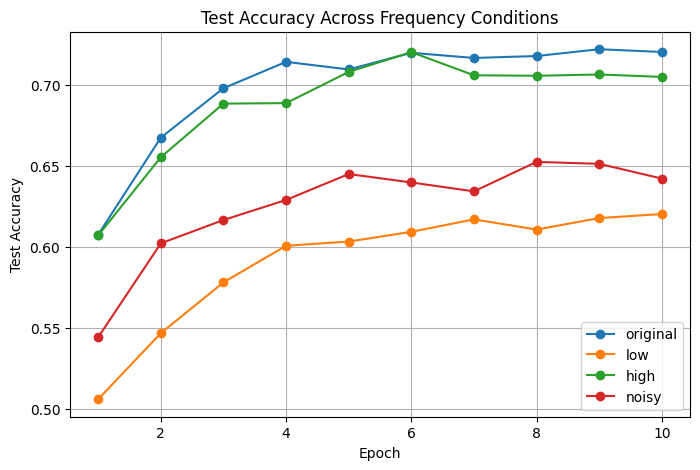

In [ ]:
plt.figure(figsize=(8, 5))

for mode in ["original", "low", "high", "noisy"]:
    subset = history_df[history_df["mode"] == mode]
    plt.plot(subset["epoch"], subset["test_acc"], marker="o", label=mode)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Across Frequency Conditions")
plt.legend()
plt.grid(True)

plt.savefig("test_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

Plotting test loss

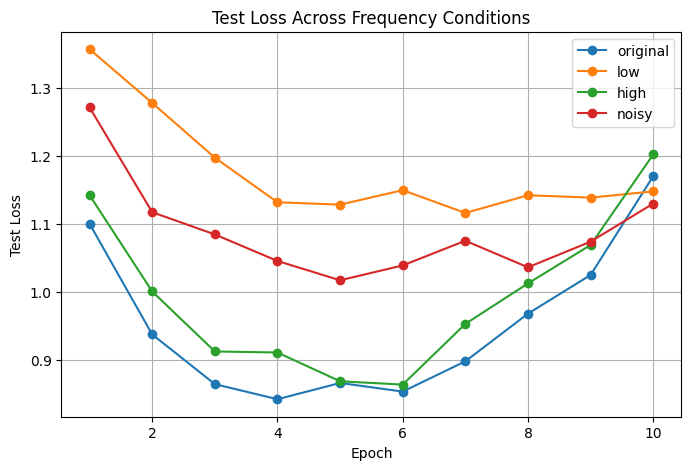

In [ ]:
plt.figure(figsize=(8, 5))

for mode in ["original", "low", "high", "noisy"]:
    subset = history_df[history_df["mode"] == mode]
    plt.plot(subset["epoch"], subset["test_loss"], marker="o", label=mode)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Across Frequency Conditions")
plt.legend()
plt.grid(True)

plt.savefig("test_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

Robustness Testing

In [ ]:
def robustness_test(model, test_modes=["original", "low", "high", "noisy"], batch_size=64):
    criterion = nn.CrossEntropyLoss()
    robustness_results = {}

    for mode in test_modes:
        _, testloader = get_dataloaders(mode=mode, batch_size=batch_size)

        test_loss, test_acc, preds, labels = evaluate(
            model, testloader, criterion
        )

        robustness_results[mode] = {
            "test_loss": test_loss,
            "test_acc": test_acc
        }

        print(f"Test mode: {mode}, Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    return pd.DataFrame(robustness_results).T

In [ ]:
robustness_df = robustness_test(
    baseline_model_test,
    test_modes=["original", "low", "high", "noisy"],
    batch_size=64
)

robustness_df.to_csv("robustness_results.csv")

robustness_df

Test mode: original, Loss: 1.1700, Acc: 0.7206
Test mode: low, Loss: 3.4974, Acc: 0.3190
Test mode: high, Loss: 2.1918, Acc: 0.5736
Test mode: noisy, Loss: 3.9763, Acc: 0.3629


,test_loss,test_acc
original,1.169963,0.7206
low,3.497406,0.3190
high,2.191824,0.5736
noisy,3.976293,0.3629


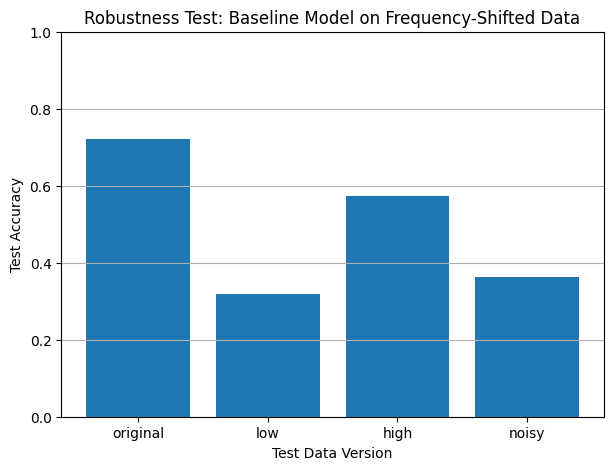

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(robustness_df.index, robustness_df["test_acc"])

plt.xlabel("Test Data Version")
plt.ylabel("Test Accuracy")
plt.title("Robustness Test: Baseline Model on Frequency-Shifted Data")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.savefig("robustness_accuracy_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

Error Analysis

In [ ]:
def collect_misclassified(model, mode="original", max_images=12):
    model.eval()

    _, testloader = get_dataloaders(mode=mode, batch_size=1)

    misclassified = []

    with torch.no_grad():
        for image, label in testloader:
            image_device = image.to(device)

            output = model(image_device)
            _, pred = torch.max(output, 1)

            if pred.item() != label.item():
                misclassified.append((image.squeeze(), label.item(), pred.item()))

            if len(misclassified) >= max_images:
                break

    return misclassified


def show_misclassified(misclassified, title="Misclassified Examples"):
    plt.figure(figsize=(12, 6))

    for i, (img, true_label, pred_label) in enumerate(misclassified):
        img = img * 0.5 + 0.5
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"True: {classes[true_label]}\nPred: {classes[pred_label]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(title.replace(" ", "_").lower() + ".png", dpi=300, bbox_inches="tight")
    plt.show()

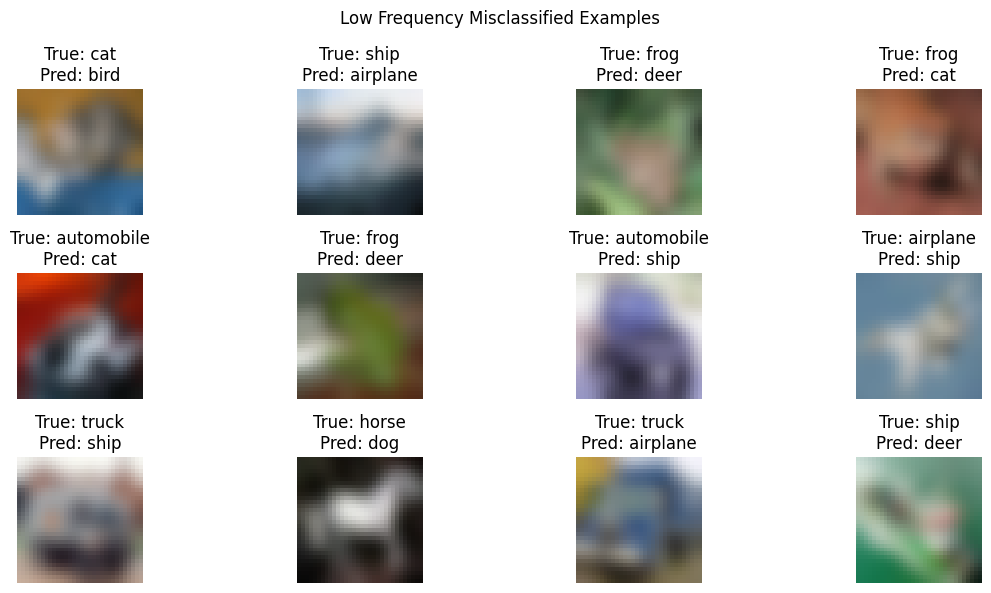

In [ ]:
misclassified_low = collect_misclassified(
    baseline_model_test,
    mode="low",
    max_images=12
)

show_misclassified(
    misclassified_low,
    title="Low Frequency Misclassified Examples"
)

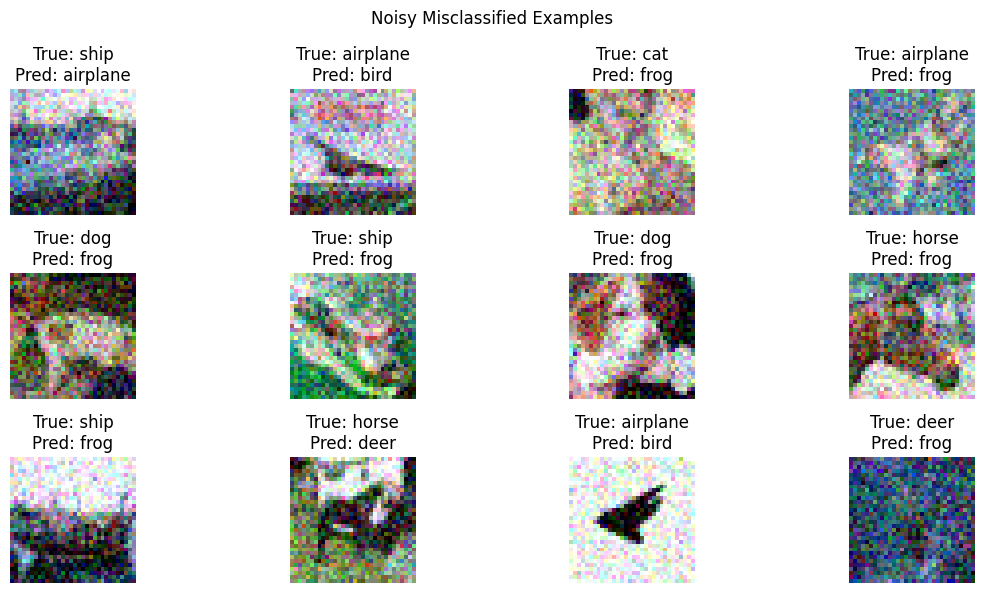

In [ ]:
misclassified_noisy = collect_misclassified(
    baseline_model_test,
    mode="noisy",
    max_images=12
)

show_misclassified(
    misclassified_noisy,
    title="Noisy Misclassified Examples"
)

Inference Efficiency

In [ ]:
def measure_inference_time(model, mode="original", batch_size=64):
    model.eval()

    _, testloader = get_dataloaders(mode=mode, batch_size=batch_size)

    total_images = 0

    # Warm-up pass
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            _ = model(images)
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            _ = model(images)
            total_images += images.size(0)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.time()

    total_time = end_time - start_time
    avg_time_per_image = total_time / total_images
    images_per_second = total_images / total_time

    return {
        "mode": mode,
        "total_images": total_images,
        "total_time_sec": total_time,
        "avg_time_per_image_sec": avg_time_per_image,
        "images_per_second": images_per_second
    }

In [ ]:
inference_results = []

models_to_test = {
    "original": baseline_model_test,
    "low": low_model,
    "high": high_model,
    "noisy": noisy_model
}

for mode, model in models_to_test.items():
    result = measure_inference_time(
        model=model,
        mode=mode,
        batch_size=64
    )
    inference_results.append(result)

inference_df = pd.DataFrame(inference_results)

inference_df.to_csv("inference_efficiency.csv", index=False)

inference_df

,mode,total_images,total_time_sec,avg_time_per_image_sec,images_per_second
0,original,10000,10.171803,0.001017,983.109924
1,low,10000,10.348299,0.001035,966.342389
2,high,10000,11.416698,0.001142,875.910043
3,noisy,10000,11.597372,0.001160,862.264344


Creating Final Results Folder

In [ ]:
import os
import shutil

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# CSV result files
csv_files = [
    "baseline_original_history.csv",
    "baseline_original_summary.csv",
    "low_frequency_history.csv",
    "low_frequency_summary.csv",
    "high_frequency_history.csv",
    "high_frequency_summary.csv",
    "noisy_history.csv",
    "noisy_summary.csv",
    "all_experiment_results.csv",
    "all_training_history.csv",
    "robustness_results.csv",
    "inference_efficiency.csv"
]

# Figure files
figure_files = [
    "frequency_versions_example.png",
    "test_accuracy_curve.png",
    "test_loss_curve.png",
    "robustness_accuracy_bar_chart.png",
    "low_frequency_misclassified_examples.png",
    "noisy_misclassified_examples.png"
]

for file in csv_files:
    if os.path.exists(file):
        shutil.copy(file, os.path.join("results", file))
    else:
        print("Missing CSV:", file)

for file in figure_files:
    if os.path.exists(file):
        shutil.copy(file, os.path.join("figures", file))
    else:
        print("Missing figure:", file)

print("Saved CSV files to /results")
print("Saved figure files to /figures")

Missing figure: frequency_versions_example.png
Saved CSV files to /results
Saved figure files to /figures


In [ ]:
import shutil

shutil.make_archive(
    "spectral_bias_cnn_outputs",
    "zip",
    ".",
    "results"
)

shutil.make_archive(
    "spectral_bias_cnn_figures",
    "zip",
    ".",
    "figures"
)

print("Created:")
print("spectral_bias_cnn_outputs.zip")
print("spectral_bias_cnn_figures.zip")

Created:
spectral_bias_cnn_outputs.zip
spectral_bias_cnn_figures.zip


Summary Methodology Diagram

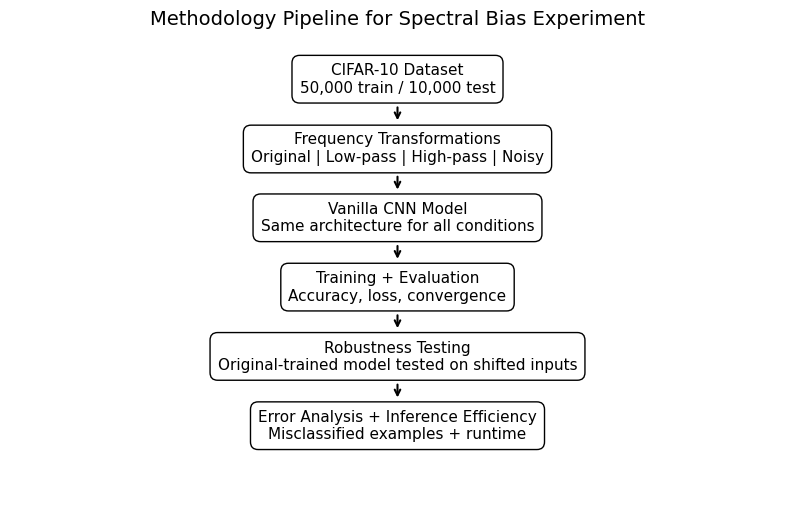

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.axis("off")

steps = [
    "CIFAR-10 Dataset\n50,000 train / 10,000 test",
    "Frequency Transformations\nOriginal | Low-pass | High-pass | Noisy",
    "Vanilla CNN Model\nSame architecture for all conditions",
    "Training + Evaluation\nAccuracy, loss, convergence",
    "Robustness Testing\nOriginal-trained model tested on shifted inputs",
    "Error Analysis + Inference Efficiency\nMisclassified examples + runtime"
]

y_positions = [0.9, 0.75, 0.6, 0.45, 0.3, 0.15]

for step, y in zip(steps, y_positions):
    plt.text(
        0.5, y, step,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white")
    )

for i in range(len(y_positions) - 1):
    plt.annotate(
        "",
        xy=(0.5, y_positions[i+1] + 0.055),
        xytext=(0.5, y_positions[i] - 0.055),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

plt.title("Methodology Pipeline for Spectral Bias Experiment", fontsize=14)
plt.savefig("methodology_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import shutil
import os

os.makedirs("figures", exist_ok=True)

if os.path.exists("methodology_diagram.png"):
    shutil.copy("methodology_diagram.png", "figures/methodology_diagram.png")
    print("methodology_diagram.png copied to figures folder")
else:
    print("methodology_diagram.png not found")

methodology_diagram.png copied to figures folder


In [ ]:
import shutil
import os

# Make sure folders exist
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Copy methodology diagram into figures folder if it exists
if os.path.exists("methodology_diagram.png"):
    shutil.copy("methodology_diagram.png", "figures/methodology_diagram.png")
    print("Added methodology_diagram.png to figures folder")

# Recreate zip files
shutil.make_archive(
    "spectral_bias_cnn_outputs",
    "zip",
    ".",
    "results"
)

shutil.make_archive(
    "spectral_bias_cnn_figures",
    "zip",
    ".",
    "figures"
)

print("Updated ZIP files:")
print("spectral_bias_cnn_outputs.zip")
print("spectral_bias_cnn_figures.zip")

Added methodology_diagram.png to figures folder
Updated ZIP files:
spectral_bias_cnn_outputs.zip
spectral_bias_cnn_figures.zip
